In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import utils.comparison_utils as cmp
import utils.comparison_utils.bad_cases as cmp_bad_cases
import utils.visualization as viz
import utils.visualization.bad_cases as viz_bad_cases

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = {
    "mid_res": {
        "train": "../output/segmentation/8.final_results/mid_res/2026-04-30_14-33-37",
        "val": "../output/segmentation/8.final_results/mid_res/2026-04-30_13-24-40",
        "test": "../output/segmentation/8.final_results/mid_res/2026-04-19_09-10-35",
    },
    "high_res": {
        "train": "../output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "val": "../output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "test": "../output/segmentation/8.final_results/high_res/2026-04-28_14-28-44",
    },
}

VALID_SPLITS = ("train", "val", "test")

# Resultados Testes - Casos Ruins

## Carregamento de dados

### Dados dos casos ruins (bad_tests)

In [4]:
bad_cases_split = "test"  # options: "train", "val" or "test"
BAD_CASES_EXPORT_DIR = "../output/segmentation/8.final_results/bad_cases_exports"

if bad_cases_split not in VALID_SPLITS:
    raise ValueError("bad_cases_split must be 'train', 'val' or 'test'.")

if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["mid_res"]:
    raise ValueError(f"Split '{bad_cases_split}' is not available for mid_res.")
if bad_cases_split not in SPLIT_PATHS_BY_RESOLUTION["high_res"]:
    print(f"Warning: split '{bad_cases_split}' is not available for high_res. Only mid_res will be shown.")

df_mid_res = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "mid_res", bad_cases_split)
df_mid_bad_res = cmp.get_bad_cases(df_mid_res)
mid_export = cmp.save_bad_cases_artifacts(
    df_bad_cases=df_mid_bad_res,
    output_dir=BAD_CASES_EXPORT_DIR,
    subset_name=bad_cases_split,
    resolution="mid_res",
)

mid_total_cases = int(df_mid_res.shape[0])
mid_bad_cases = int(df_mid_bad_res.shape[0])
mid_bad_percent = (100 * mid_bad_cases / mid_total_cases) if mid_total_cases > 0 else 0.0

bad_summary_rows = [
    {
        "resolution": "mid_res",
        "subset": bad_cases_split,
        "total_cases": mid_total_cases,
        "bad_cases": mid_bad_cases,
        "bad_cases_percent": mid_bad_percent,
        "csv_path": mid_export["csv_path"],
        "json_path": mid_export["json_path"],
    }
]

df_high_res = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, "high_res", bad_cases_split)
if df_high_res is not None:
    df_high_bad_res = cmp.get_bad_cases(df_high_res)
    high_export = cmp.save_bad_cases_artifacts(
        df_bad_cases=df_high_bad_res,
        output_dir=BAD_CASES_EXPORT_DIR,
        subset_name=bad_cases_split,
        resolution="high_res",
    )

    high_total_cases = int(df_high_res.shape[0])
    high_bad_cases = int(df_high_bad_res.shape[0])
    high_bad_percent = (100 * high_bad_cases / high_total_cases) if high_total_cases > 0 else 0.0

    bad_summary_rows.append(
        {
            "resolution": "high_res",
            "subset": bad_cases_split,
            "total_cases": high_total_cases,
            "bad_cases": high_bad_cases,
            "bad_cases_percent": high_bad_percent,
            "csv_path": high_export["csv_path"],
            "json_path": high_export["json_path"],
        }
    )
else:
    df_high_res = pd.DataFrame(columns=df_mid_res.columns)
    df_high_bad_res = pd.DataFrame(columns=df_mid_bad_res.columns)

bad_summary_df = pd.DataFrame(bad_summary_rows)

## Casos Ruins por Subset

### Validação (Val)

#### Carregamento

In [18]:
bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

val_data = cmp_bad_cases.prepare_bad_cases_for_subset(
    split_paths_by_resolution=SPLIT_PATHS_BY_RESOLUTION,
    split_name="val",
    output_dir=bad_cases_export_dir,
    valid_splits=VALID_SPLITS,
)

df_mid_val = val_data["df_mid"]
df_high_val = val_data["df_high"]
df_mid_val_bad = val_data["df_mid_bad"]
df_high_val_bad = val_data["df_high_bad"]
val_mid_export = val_data["mid_export"]
val_high_export = val_data["high_export"]

#### Dice Score dos casos ruins (barra)

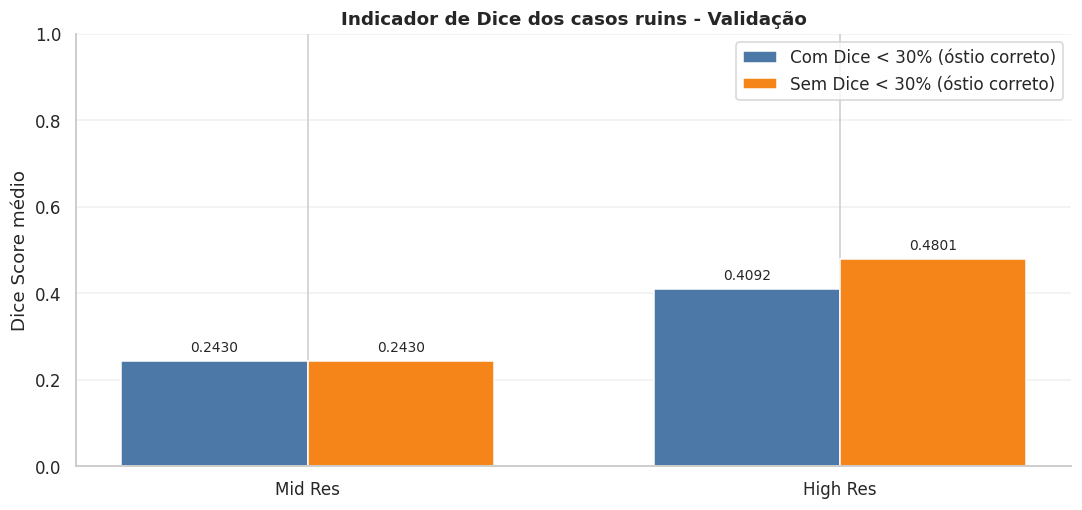

In [19]:
val_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_val_bad,
    df_high_val_bad,
    "Validação",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)

#### Distribuição de casos ruins

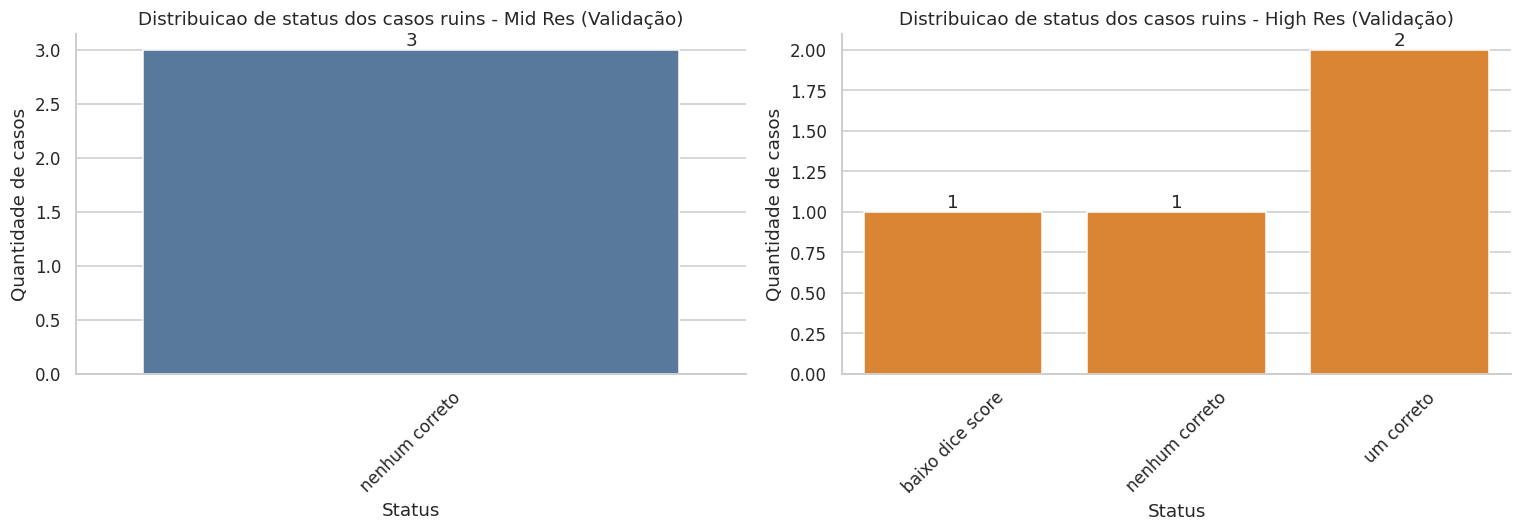

In [20]:
viz.bad_cases.plot_bad_cases_by_subset(
    df_mid_val,
    df_high_val,
    df_mid_val_bad,
    df_high_val_bad,
    "Validação",
)

#### Comparativo entre resoluções (Mid vs High)

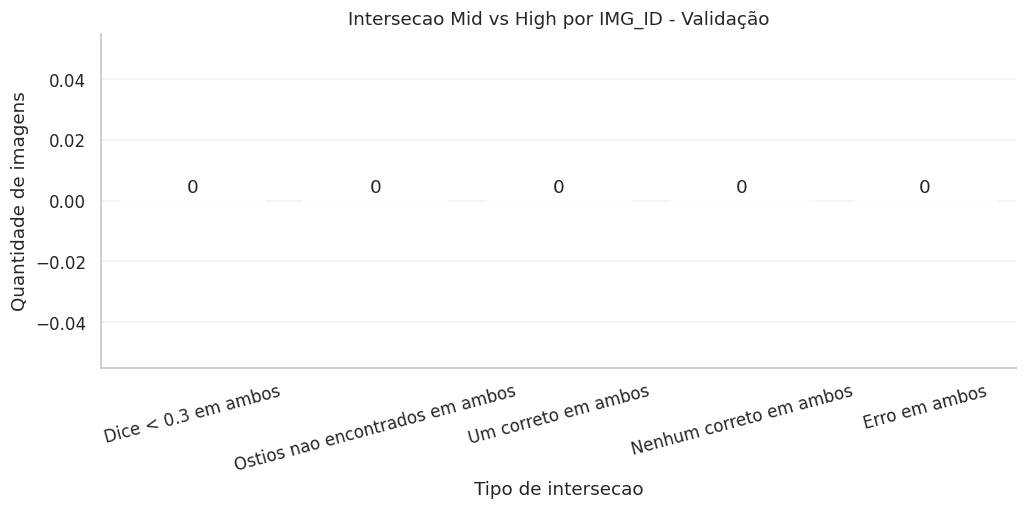

In [21]:
val_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_val, df_high_val, "Validação")

### Treino (Train)

#### Carregamento

In [22]:
bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

train_data = cmp_bad_cases.prepare_bad_cases_for_subset(
    split_paths_by_resolution=SPLIT_PATHS_BY_RESOLUTION,
    split_name="train",
    output_dir=bad_cases_export_dir,
    valid_splits=VALID_SPLITS,
)

df_mid_train = train_data["df_mid"]
df_high_train = train_data["df_high"]
df_mid_train_bad = train_data["df_mid_bad"]
df_high_train_bad = train_data["df_high_bad"]
train_mid_export = train_data["mid_export"]
train_high_export = train_data["high_export"]

#### Dice Score dos casos ruins (barra)

,resolution,com_dice_baixo_ok,sem_dice_baixo_ok,n_total_dice,n_removidos_dice_baixo_ok
0,Mid Res,0.243130,0.265627,56,9
1,High Res,0.258174,0.277039,86,11


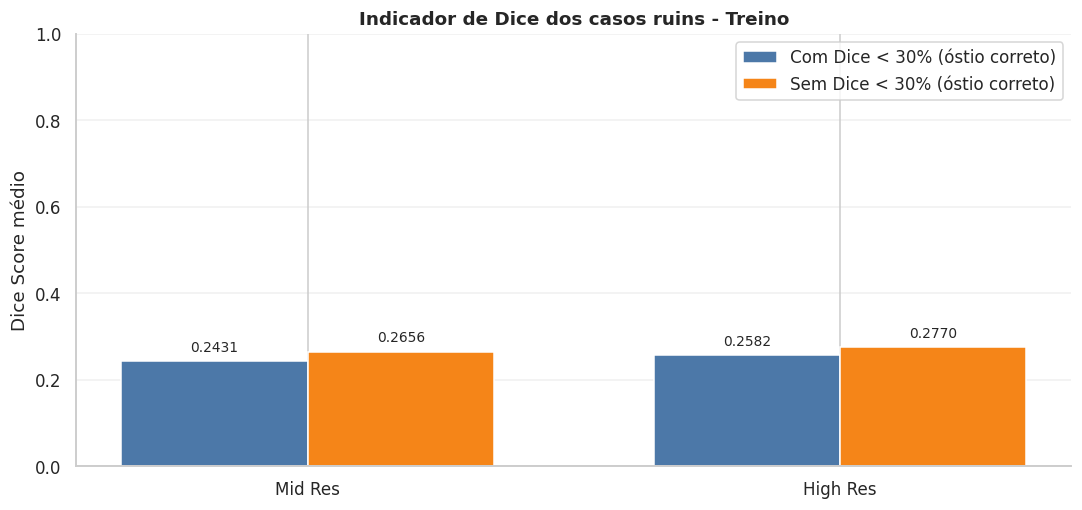

In [23]:
train_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_train_bad,
    df_high_train_bad,
    "Treino",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)
display(train_bad_dice_indicator_df)

#### Distribuição de casos ruins

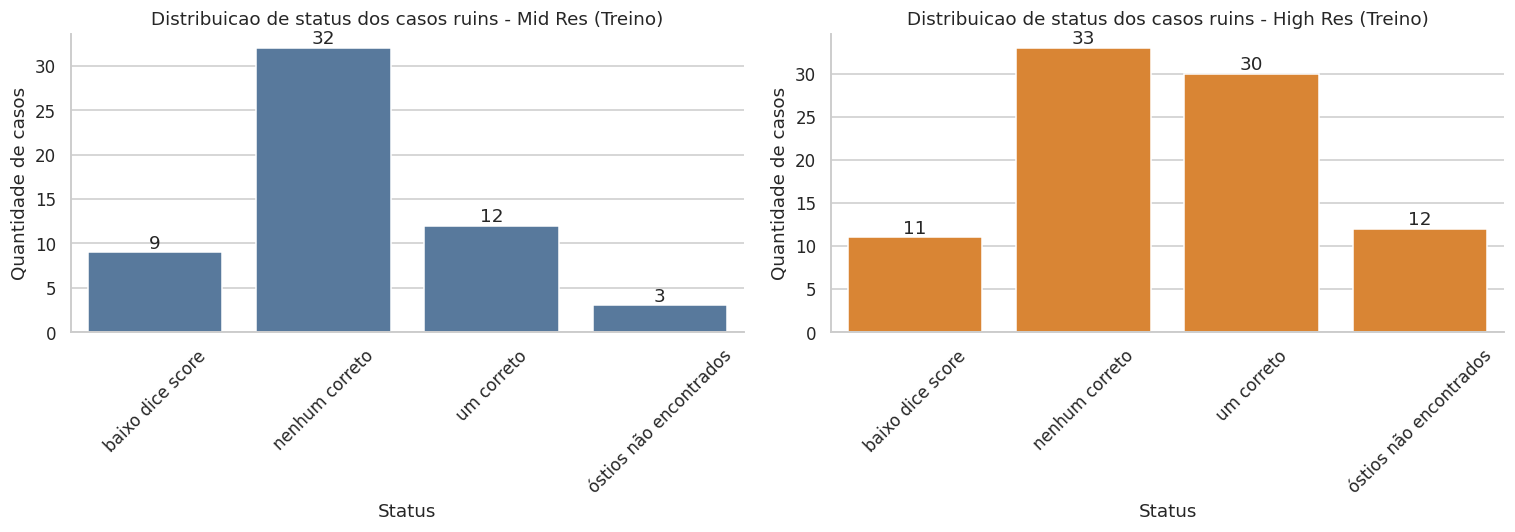

In [24]:
viz.bad_cases.plot_bad_cases_by_subset(df_mid_train, df_high_train, df_mid_train_bad, df_high_train_bad, "Treino")

#### Comparativo entre resoluções (Mid vs High)

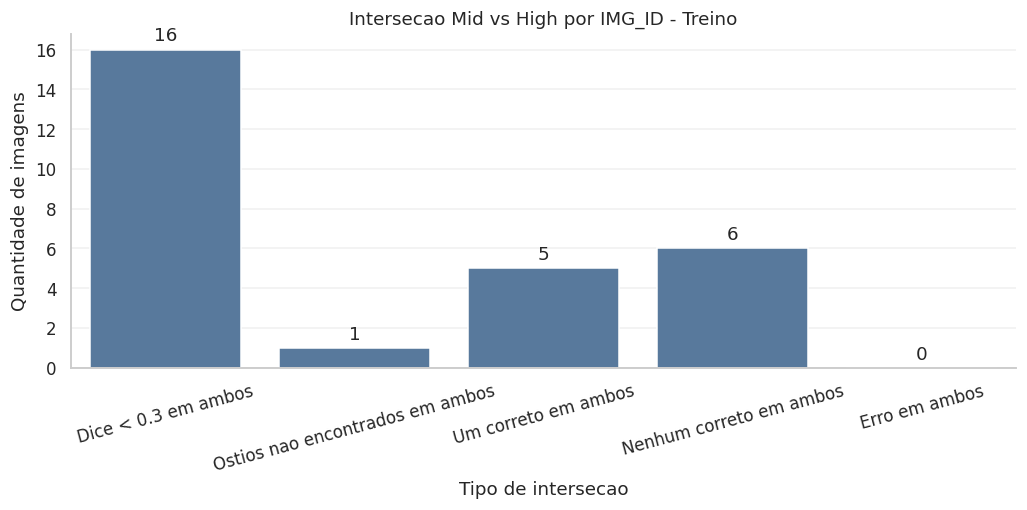

In [25]:
train_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_train, df_high_train, "Treino")

### Teste (Test)

#### Carregamento

In [26]:
bad_cases_export_dir = globals().get(
    "BAD_CASES_EXPORT_DIR",
    "../output/segmentation/8.final_results/bad_cases_exports",
)

test_data = cmp_bad_cases.prepare_bad_cases_for_subset(
    split_paths_by_resolution=SPLIT_PATHS_BY_RESOLUTION,
    split_name="test",
    output_dir=bad_cases_export_dir,
    valid_splits=VALID_SPLITS,
)

df_mid_test = test_data["df_mid"]
df_high_test = test_data["df_high"]
df_mid_test_bad = test_data["df_mid_bad"]
df_high_test_bad = test_data["df_high_bad"]
test_mid_export = test_data["mid_export"]
test_high_export = test_data["high_export"]

#### Dice Score dos casos ruins (barra)

,resolution,com_dice_baixo_ok,sem_dice_baixo_ok,n_total_dice,n_removidos_dice_baixo_ok
0,Mid Res,0.245439,0.276408,137,27
1,High Res,0.251734,0.263805,227,27


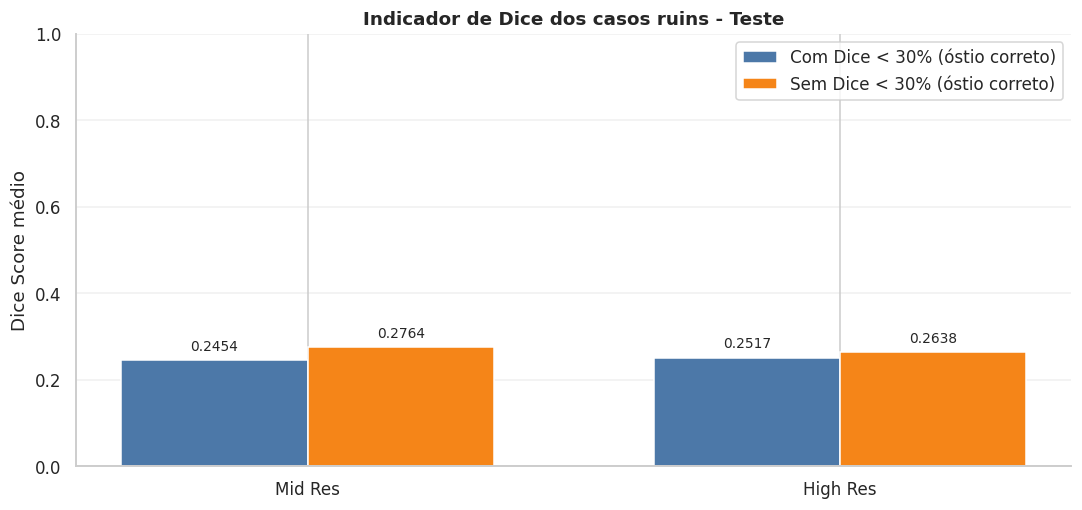

In [27]:
test_bad_dice_indicator_df = viz_bad_cases.plot_bad_dice_indicator(
    df_mid_test_bad,
    df_high_test_bad,
    "Teste",
    summarize_bad_dice_fn=cmp_bad_cases.summarize_bad_dice_with_threshold,
    dice_threshold=0.3,
)
display(test_bad_dice_indicator_df)

#### Distribuição de casos ruins

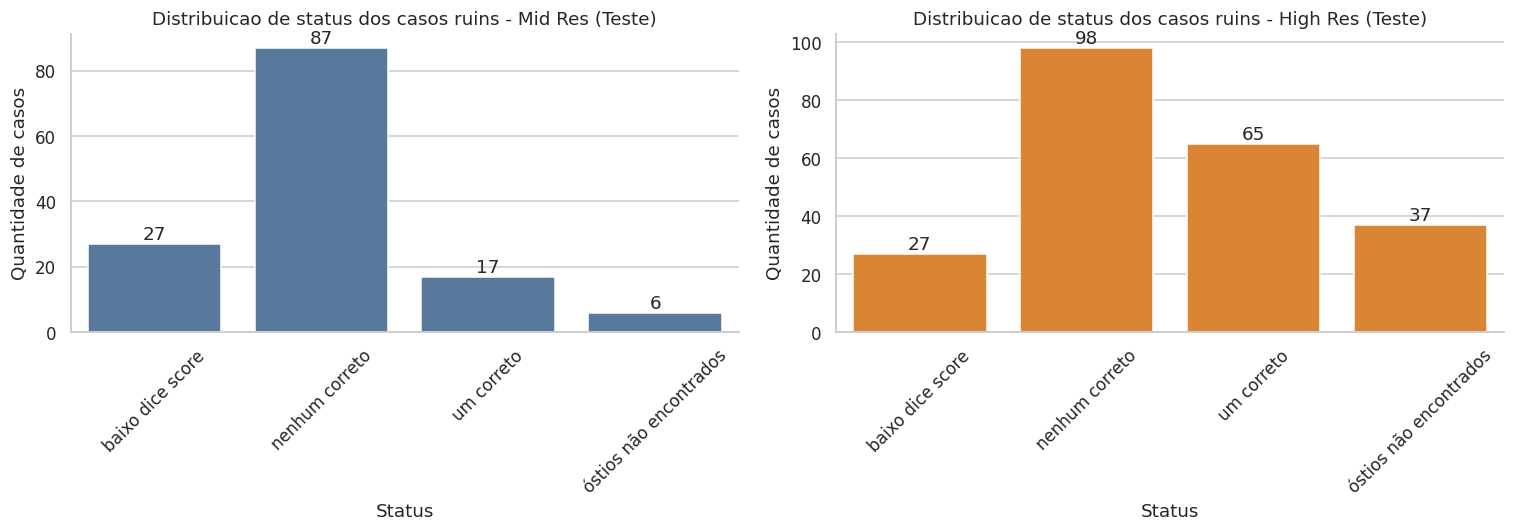

In [28]:
viz.bad_cases.plot_bad_cases_by_subset(df_mid_test, df_high_test, df_mid_test_bad, df_high_test_bad, "Teste")

#### Comparativo entre resoluções (Mid vs High)

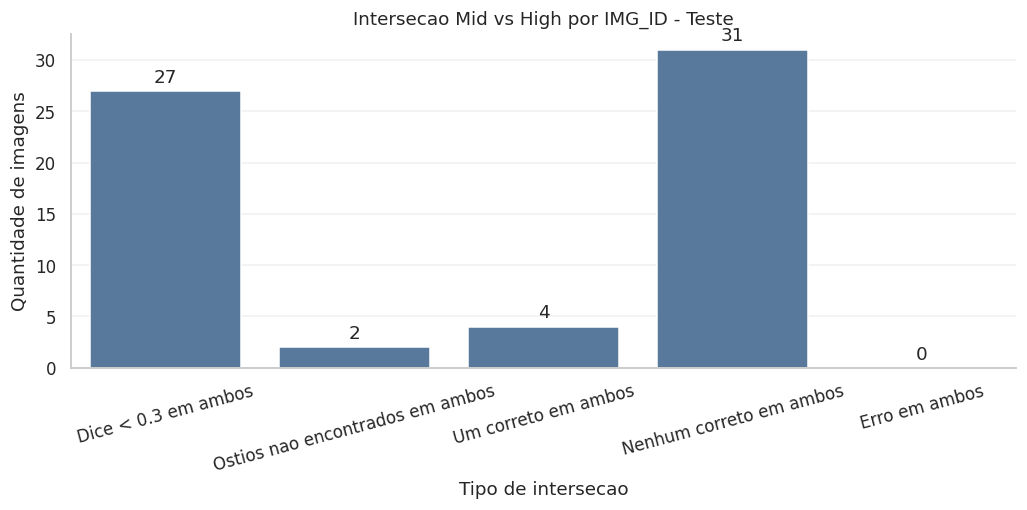

In [29]:
test_shared_bad = viz.bad_cases.compare_shared_bad_cases(df_mid_test, df_high_test, "Teste")